# Import Libraries

In [1]:
import numpy as np
import torch.nn as nn
import random

from torch.utils.data import DataLoader
from torchvision import models, transforms

In [2]:
from aux_functions import *

d) Compare the performance of different models and strategies. (20 points) 
1. Use at least three transfer models that you've trained using task(b) and perform ensemble 
learning. Try out the following ensemble techniques (Stacking, Boosting, Weighted Average, 
Max Voting, Bagging) and analyze whether the performance increases or not.  
2. Try out different image preprocessing techniques such as, Ben Graham, Circle Cropping, 
CLAHE, adding gaussian blur, sharpening up the images etc. 

In [3]:
class CutOut(object):
    def __init__(self, mask_size, p=0.5):
        self.mask_size = mask_size
        self.p = p

    def __call__(self, img):
        if np.random.rand() > self.p:
            return img

        # Ensure the image is a tensor
        if not isinstance(img, torch.Tensor):
            raise TypeError('Input image must be a torch.Tensor')

        # Get height and width of the image
        h, w = img.shape[1], img.shape[2]
        mask_size_half = self.mask_size // 2
        offset = 1 if self.mask_size % 2 == 0 else 0

        cx = np.random.randint(mask_size_half, w + offset - mask_size_half)
        cy = np.random.randint(mask_size_half, h + offset - mask_size_half)

        xmin, xmax = cx - mask_size_half, cx + mask_size_half + offset
        ymin, ymax = cy - mask_size_half, cy + mask_size_half + offset
        xmin, xmax = max(0, xmin), min(w, xmax)
        ymin, ymax = max(0, ymin), min(h, ymax)

        img[:, ymin:ymax, xmin:xmax] = 0
        return img
    
class SLORandomPad:
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        pad_width = max(0, self.size[0] - img.width)
        pad_height = max(0, self.size[1] - img.height)
        pad_left = random.randint(0, pad_width)
        pad_top = random.randint(0, pad_height)
        pad_right = pad_width - pad_left
        pad_bottom = pad_height - pad_top
        return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom))


class FundRandomRotate:
    def __init__(self, prob, degree):
        self.prob = prob
        self.degree = degree

    def __call__(self, img):
        if random.random() < self.prob:
            angle = random.uniform(-self.degree, self.degree)
            return transforms.functional.rotate(img, angle)
        return img

# Hyper Parameters

In [4]:
# Hyper Parameters
batch_size = 24
num_classes = 5  # 5 DR levels

# Transformers

In [5]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((210, 210)),
    SLORandomPad((224, 224)),
    FundRandomRotate(prob=0.5, degree=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=(0.1, 0.9)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Main Loop

In [6]:
# Define the weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Use GPU device is possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


# Single Models

In [7]:
# Choose between 'single image' and 'dual images' pipeline
# This will affect the model definition, dataset pipeline, training and evaluation

mode = 'single'  # forward single image to the model each time

In [8]:
# Create datasets
train_dataset = RetinopathyDataset('./DeepDRiD/train.csv', './DeepDRiD/train/', transform_train, mode)
val_dataset = RetinopathyDataset('./DeepDRiD/val.csv', './DeepDRiD/val/', transform_test, mode)
test_dataset = RetinopathyDataset('./DeepDRiD/test.csv', './DeepDRiD/test/', transform_test, mode, test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
class LoadModels(nn.Module):
    def __init__(self, model_name, num_classes=5):
        super(LoadModels, self).__init__()
        self.model_name = model_name
        if self.model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=False)
            num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_ftrs, num_classes)
            state_dict = torch.load('./resnet18.pth', map_location='cpu')
        elif self.model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=False)
            num_ftrs = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_ftrs, num_classes)
            state_dict = torch.load('./resnet34.pth', map_location='cpu')
        elif self.model_name == 'vgg16':
            self.backbone = models.vgg16(pretrained=False)
            num_ftrs = self.backbone.classifier[6].in_features  
            self.backbone.classifier[6] = nn.Linear(num_ftrs, num_classes)
            state_dict = torch.load('./vgg16.pth', map_location='cpu')
        elif self.model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=False)
            num_ftrs = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Linear(num_ftrs, num_classes)
            state_dict = torch.load('./efficientnet_b0.pth', map_location='cpu')
        elif self.model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=False)
            num_ftrs = self.backbone.classifier.in_features 
            self.backbone.classifier = nn.Linear(num_ftrs, num_classes)
            state_dict = torch.load('./densenet121.pth', map_location='cpu')
        
        # Remove 'backbone.' prefix from keys
        new_state_dict = {}
        for k, v in state_dict.items():
            if k.startswith('backbone.'):
                new_state_dict[k[len('backbone.'):]] = v
            else:
                new_state_dict[k] = v
        self.backbone.load_state_dict(new_state_dict, strict=True)

    def forward(self, x):
        return self.backbone(x)

In [10]:
resnet18 = LoadModels('resnet18')
resnet34 = LoadModels('resnet34')
vgg16 = LoadModels('vgg16')
efficientnet_b0 = LoadModels('efficientnet_b0')
densenet121 = LoadModels('densenet121')

models = [resnet18, resnet34, vgg16, efficientnet_b0, densenet121]
[model.to(device) for model in models]
# Switch all models to evaluation mode
[model.eval() for model in models]

c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\murat\anaconda3\envs\project\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\murat\AppData\Local\Temp\ipykernel_29988\4284657774.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

C:\Users\murat\AppData\Local\Temp\ipykernel_29988\4284657774.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./resnet34.pth', map_location='cpu

[LoadModels(
   (backbone): ResNet(
     (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (layer1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       )
       (1): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [11]:
val_metrics, val_loss= evaluate_model(criterion, resnet18, val_loader, device)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print("ResNet18 - Metrics:")
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')
val_metrics, val_loss= evaluate_model(criterion, resnet34, val_loader, device)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print("ResNet34 - Metrics:")
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')
val_metrics, val_loss= evaluate_model(criterion, vgg16, val_loader, device)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print("VGG16 - Metrics:")
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')
val_metrics, val_loss= evaluate_model(criterion, efficientnet_b0, val_loader, device)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print("EfficientNet B0 - Metrics:")
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')
val_metrics, val_loss= evaluate_model(criterion, densenet121, val_loader, device)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print("DenseNet121 - Metrics:")
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')


Evaluating: 100%|██████████| 17/17 [00:02<00:00,  6.90 batch/s]
ResNet18 - Metrics:
[Val] Kappa: 0.8467 Accuracy: 0.6925 Precision: 0.6789 Recall: 0.6925
Evaluating: 100%|██████████| 17/17 [00:02<00:00,  7.13 batch/s]
ResNet34 - Metrics:
[Val] Kappa: 0.8638 Accuracy: 0.7100 Precision: 0.6686 Recall: 0.7100
Evaluating: 100%|██████████| 17/17 [00:03<00:00,  4.28 batch/s]
VGG16 - Metrics:
[Val] Kappa: 0.8367 Accuracy: 0.6925 Precision: 0.6239 Recall: 0.6925
Evaluating: 100%|██████████| 17/17 [00:02<00:00,  7.58 batch/s]
EfficientNet B0 - Metrics:
[Val] Kappa: 0.8494 Accuracy: 0.7375 Precision: 0.7226 Recall: 0.7375
Evaluating: 100%|██████████| 17/17 [00:03<00:00,  5.61 batch/s]
DenseNet121 - Metrics:
[Val] Kappa: 0.8702 Accuracy: 0.6900 Precision: 0.6754 Recall: 0.6900


In [12]:
def weighted_average_ensemble(models, inputs, weights):
    outputs = [model(inputs) * weight for model, weight in zip(models, weights)]
    avg_output = torch.stack(outputs).sum(dim=0)
    return avg_output

def max_voting_ensemble(models, inputs):
    outputs = [model(inputs) for model in models]
    votes = [torch.argmax(output, dim=1) for output in outputs]
    votes = torch.stack(votes, dim=1)
    majority_vote, _ = torch.mode(votes, dim=1)
    return majority_vote

def bagging_ensemble(models, inputs):
    outputs = [model(inputs) for model in models]
    avg_output = torch.stack(outputs).mean(dim=0)
    return avg_output

def evaluate_ensemble(criterion, models, val_loader, device, ensemble_method, weights=None):
    for model in models:
        model.to(device)
        model.eval()

    all_preds = []
    all_labels = []
    all_image_ids = []

    with tqdm(total=len(val_loader), desc=f'Evaluating', unit=' batch', file=sys.stdout) as pbar:
        for i, data in enumerate(val_loader):
            images, labels = data

            if not isinstance(images, list):
                images = images.to(device)  # single image case
            else:
                images = [x.to(device) for x in images]  # dual images case

            with torch.no_grad():
                if ensemble_method == 'weighted_average':
                    outputs = weighted_average_ensemble(models, images, weights)
                    preds = torch.argmax(outputs, dim=1)
                elif ensemble_method == 'max_voting':
                    preds = max_voting_ensemble(models, images)
                    outputs = torch.stack([model(images) for model in models]).mean(dim=0)  # Dummy output for loss calculation
                elif ensemble_method == 'bagging':
                    outputs = bagging_ensemble(models, images)
                    preds = torch.argmax(outputs, dim=1)
                else:
                    raise ValueError("Invalid ensemble method")

                val_loss = criterion(outputs, labels.to(device).long())
                val_loss = val_loss.cpu().numpy()

            if not isinstance(images, list):
                # single image case
                all_preds.extend(preds.cpu().numpy())
                image_ids = [
                    os.path.basename(val_loader.dataset.data[idx]['img_path']) for idx in
                    range(i * val_loader.batch_size, i * val_loader.batch_size + len(images))
                ]
                all_image_ids.extend(image_ids)
                all_labels.extend(labels.numpy())
            else:
                # dual images case
                for k in range(2):
                    all_preds.extend(preds.cpu().numpy())
                    image_ids = [
                        os.path.basename(val_loader.dataset.data[idx][f'img_path{k + 1}']) for idx in
                        range(i * val_loader.batch_size, i * val_loader.batch_size + len(images[k]))
                    ]
                    all_image_ids.extend(image_ids)
                    all_labels.extend(labels.numpy())

            pbar.update(1)

    metrics = compute_metrics(all_preds, all_labels)
    return metrics, val_loss


def test_ensemble(models, test_loader, device, ensemble_method, weights=None, prediction_path='./test_predictions.csv'):

    all_preds = []
    all_image_ids = []

    with tqdm(total=len(test_loader), desc=f'Evaluating', unit=' batch', file=sys.stdout) as pbar:
        for i, data in enumerate(test_loader):
            images = data

            if not isinstance(images, list):
                images = images.to(device)  # single image case
            else:
                images = [x.to(device) for x in images]  # dual images case

            with torch.no_grad():
                if ensemble_method == 'weighted_average':
                    outputs = weighted_average_ensemble(models, images, weights)
                    preds = torch.argmax(outputs, dim=1)
                elif ensemble_method == 'max_voting':
                    preds = max_voting_ensemble(models, images)
                elif ensemble_method == 'bagging':
                    outputs = bagging_ensemble(models, images)
                    preds = torch.argmax(outputs, dim=1)
                else:
                    raise ValueError("Invalid ensemble method")

            if not isinstance(images, list):
                # single image case
                all_preds.extend(preds.cpu().numpy())
                image_ids = [
                    os.path.basename(test_loader.dataset.data[idx]['img_path']) for idx in
                    range(i * test_loader.batch_size, i * test_loader.batch_size + len(images))
                ]
                all_image_ids.extend(image_ids)
            else:
                # dual images case
                for k in range(2):
                    all_preds.extend(preds.cpu().numpy())
                    image_ids = [
                        os.path.basename(test_loader.dataset.data[idx][f'img_path{k + 1}']) for idx in
                        range(i * test_loader.batch_size, i * test_loader.batch_size + len(images[k]))
                    ]
                    all_image_ids.extend(image_ids)

            pbar.update(1)

    # Save predictions to csv file for Kaggle online evaluation
    df = pd.DataFrame({
        'ID': all_image_ids,
        'TARGET': all_preds
    })
    df.to_csv(prediction_path, index=False)
    print(f'[Test] Save predictions to {os.path.abspath(prediction_path)}')

In [13]:
# Example usage for validation
weights = [0.2, 0.2, 0.2, 0.2, 0.2]  # Adjust weights as needed

print(f'Evaluating Weighted Average Ensemble')
val_metrics, val_loss = evaluate_ensemble(criterion, models, val_loader, device, 'weighted_average', weights)
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

print(f'Evaluating Max Voting Ensemble')
val_metrics, val_loss = evaluate_ensemble(criterion, models, val_loader, device, 'max_voting')
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

print(f'Evaluating Bagging Ensemble')
val_metrics, val_loss = evaluate_ensemble(criterion, models, val_loader, device, 'bagging')
val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

# Example usage for testing
print(f'Testing Weighted Average Ensemble')
test_ensemble(models, test_loader, device, 'weighted_average', weights, prediction_path='./test_predictions_weighted_average.csv')

print(f'Testing Max Voting Ensemble')
test_ensemble(models, test_loader, device, 'max_voting', prediction_path='./test_predictions_max_voting.csv')

print(f'Testing Bagging Ensemble')
test_ensemble(models, test_loader, device, 'bagging', prediction_path='./test_predictions_bagging.csv')

Evaluating Weighted Average Ensemble
Evaluating:   0%|          | 0/17 [00:00<?, ? batch/s]

Evaluating: 100%|██████████| 17/17 [00:06<00:00,  2.45 batch/s]
[Val] Kappa: 0.8732 Accuracy: 0.7350 Precision: 0.7194 Recall: 0.7350
Evaluating Max Voting Ensemble
Evaluating: 100%|██████████| 17/17 [00:12<00:00,  1.38 batch/s]
[Val] Kappa: 0.8737 Accuracy: 0.7325 Precision: 0.7150 Recall: 0.7325
Evaluating Bagging Ensemble
Evaluating: 100%|██████████| 17/17 [00:06<00:00,  2.44 batch/s]
[Val] Kappa: 0.8732 Accuracy: 0.7350 Precision: 0.7194 Recall: 0.7350
Testing Weighted Average Ensemble
Evaluating: 100%|██████████| 17/17 [00:06<00:00,  2.46 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions_weighted_average.csv
Testing Max Voting Ensemble
Evaluating: 100%|██████████| 17/17 [00:06<00:00,  2.46 batch/s]
[Test] Save predictions to c:\Users\murat\Documents\Deep_Learning\Final Project\test_predictions_max_voting.csv
Testing Bagging Ensemble
Evaluating: 100%|██████████| 17/17 [00:06<00:00,  2.46 batch/s]
[Test] Save predictions to c:\

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

import numpy as np

def stacking_boosting_ensemble(models, train_loader, val_loader, device):
    # Collect predictions from base models
    train_preds = []
    train_labels = []
    val_preds = []
    val_labels = []

    for model_index, model in enumerate(models):
        preds = []
        # Collect training predictions
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                outputs = model(images)
                probabilities = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
                preds.extend(probabilities)
                # Collect labels only once
                if model_index == 0:
                    train_labels.extend(labels.cpu().numpy())
        train_preds.append(np.vstack(preds))
        
        preds = []
        # Collect validation predictions
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                probabilities = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
                preds.extend(probabilities)
                # Collect labels only once
                if model_index == 0:
                    val_labels.extend(labels.cpu().numpy())
        val_preds.append(np.vstack(preds))

    train_preds = np.concatenate(train_preds, axis=1)
    val_preds = np.concatenate(val_preds, axis=1)
    train_labels = np.array(train_labels)
    val_labels = np.array(val_labels)

    # Train meta-model
    meta_model = LogisticRegression()
    meta_model.fit(train_preds, train_labels)

    # Evaluate meta-model
    val_meta_preds = meta_model.predict(val_preds)
    val_metrics = compute_metrics(val_meta_preds, val_labels)
    val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
    print(f'Stacking Ensemble Metrics:')
    print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')
    
    # Train boosting model
    base_estimator = DecisionTreeClassifier(max_depth=5)
    boosting_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50)
    boosting_model.fit(train_preds, train_labels)

    # Evaluate boosting model
    val_boosting_preds = boosting_model.predict(val_preds)
    val_metrics = compute_metrics(val_boosting_preds, val_labels)
    val_kappa, val_accuracy, val_precision, val_recall = val_metrics[:4]
    print(f'Boosting Ensemble Metrics:')
    print(f'[Val] Kappa: {val_kappa:.4f} Accuracy: {val_accuracy:.4f} '
              f'Precision: {val_precision:.4f} Recall: {val_recall:.4f}')

    return meta_model, boosting_model


In [81]:
# Evaluate Stacking Ensemble
meta_model, boosting_model = stacking_boosting_ensemble(models, train_loader, val_loader, device)


Stacking Ensemble Metrics:
[Val] Kappa: 0.8562 Accuracy: 0.7100 Precision: 0.7018 Recall: 0.7100
Boosting Ensemble Metrics:
[Val] Kappa: 0.8465 Accuracy: 0.6900 Precision: 0.6802 Recall: 0.6900


# Preprocessing

In [90]:
import cv2
import numpy as np
from PIL import ImageFilter
from PIL import Image, ImageDraw
from PIL import Image, ImageOps

def ben_graham_preprocessing_pil(img, target_size):
    """
    Resizes an image to square dimensions while preserving its aspect ratio 
    and adding padding using Pillow.
    
    Args:
        img: Input image (PIL Image).
        target_size: Target size for the square image.
    
    Returns:
        Preprocessed image (PIL Image).
    """
    img = img.copy()  # Make a copy of the original image

    # Resize the image while maintaining the aspect ratio
    img.thumbnail((target_size, target_size), resample=Image.Resampling.LANCZOS)

    # Add padding to make the image square
    delta_w = target_size - img.size[0]
    delta_h = target_size - img.size[1]
    padding = (delta_w // 2, delta_h // 2, delta_w - delta_w // 2, delta_h - delta_h // 2)
    padded_img = ImageOps.expand(img, padding, fill="black")  # Black background for padding

    return padded_img


def circle_crop_pil(img):
    """
    Performs circular cropping on an image using Pillow.
    Args:
        img: Input image (PIL Image).
    Returns:
        Cropped image with a circular region (PIL Image).
    """
    mask = Image.new('L', img.size, 0)
    draw = ImageDraw.Draw(mask)
    center = (img.size[0] // 2, img.size[1] // 2)
    radius = min(img.size[0] // 2, img.size[1] // 2)
    draw.ellipse((center[0] - radius, center[1] - radius, center[0] + radius, center[1] + radius), fill=255)

    # Apply mask
    result = Image.new("RGB", img.size)
    result.paste(img, mask=mask)
    return result


def apply_clahe_pil(img):
    """
    Applies CLAHE using OpenCV to an image converted via Pillow.
    Args:
        img: Input image (PIL Image).
    Returns:
        CLAHE-processed image (PIL Image).
    """
    # Convert PIL image to NumPy array
    img_array = np.array(img)

    if len(img_array.shape) == 3:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img_array)

    # Convert back to PIL Image
    return Image.fromarray(clahe_img)


def add_gaussian_blur_pil(img, radius=2):
    """
    Adds Gaussian Blur to an image using Pillow.
    Args:
        img: Input image (PIL Image).
        radius: The radius of the Gaussian filter (default=2).
    Returns:
        Blurred image (PIL Image).
    """
    return img.filter(ImageFilter.GaussianBlur(radius))


def sharpen_image_pil(img):
    """
    Sharpens an image using Pillow's built-in filter.
    Args:
        img: Input image (PIL Image).
    Returns:
        Sharpened image (PIL Image).
    """
    return img.filter(ImageFilter.SHARPEN)


def preprocess_image_pipeline_pil(img, size=256):
    """
    Applies a preprocessing pipeline using Pillow that includes resizing, CLAHE, blurring, and sharpening.
    Args:
        img: Input image (PIL Image).
        size: Target size for resizing with square padding.
    Returns:
        Dictionary containing all versions of the preprocessed image.
    """
    processed_imgs = {}

    # Ben Graham Preprocessing (resize and pad)
    processed_imgs['ben_graham'] = ben_graham_preprocessing_pil(img, size)

    # Circle Cropping
    processed_imgs['circle_crop'] = circle_crop_pil(img)

    # Apply CLAHE
    processed_imgs['clahe'] = apply_clahe_pil(img)

    # Add Gaussian Blur
    processed_imgs['blur'] = add_gaussian_blur_pil(img)

    # Sharpen the Image
    processed_imgs['sharpen'] = sharpen_image_pil(img)

    return processed_imgs

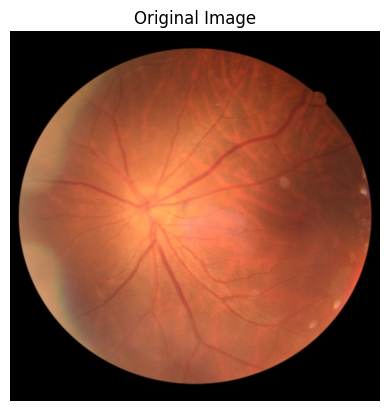

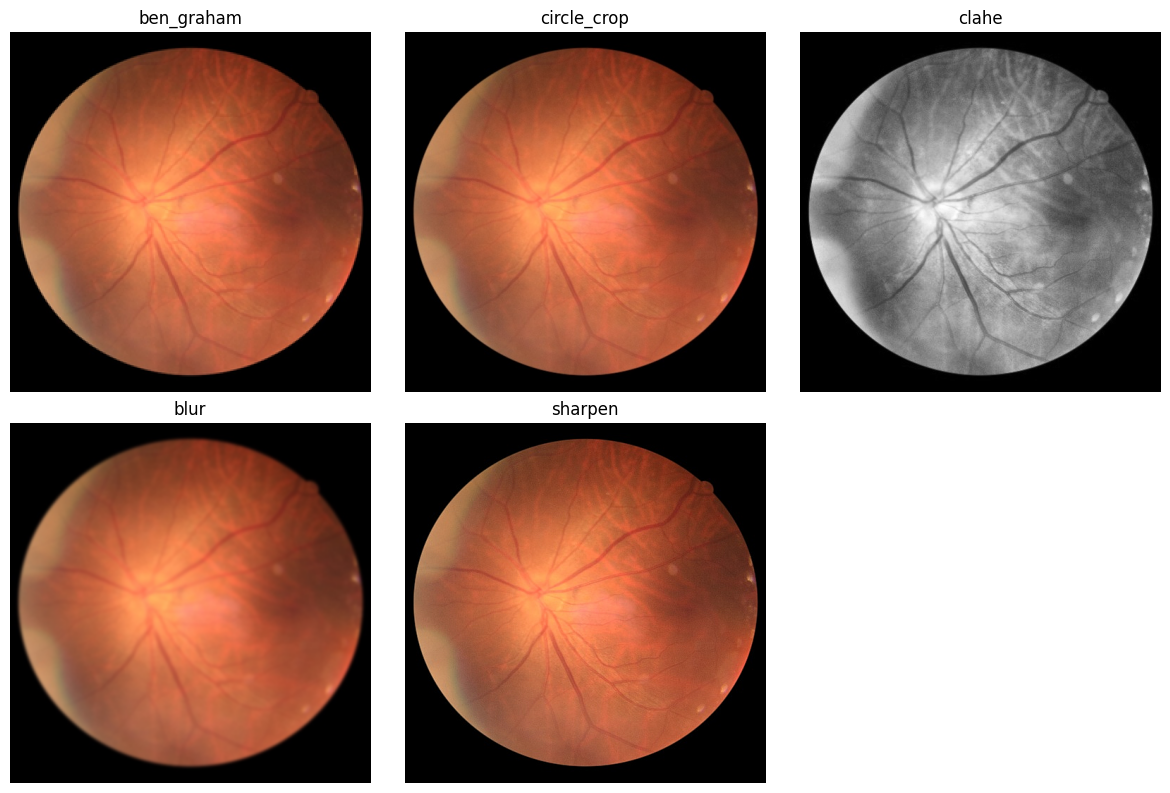

In [97]:
import matplotlib.pyplot as plt
from PIL import Image
input_image = Image.open(r"C:\Users\murat\Documents\Deep_Learning\Final Project\DeepDRiD\train\5\5_l1.jpg").convert('RGB')

# Show original image
plt.imshow(input_image)
plt.title("Original Image")
plt.axis("off")  # Turn off axis labels

# Apply the preprocessing pipeline
preprocessed_imgs = preprocess_image_pipeline_pil(input_image)

# Visualize the results
titles = list(preprocessed_imgs.keys())
plt.figure(figsize=(12, 8))

for idx, (key, processed_img) in enumerate(preprocessed_imgs.items()):
    plt.subplot(2, 3, idx + 1)
    plt.imshow(processed_img, cmap="gray")
    plt.title(key)
    plt.axis('off')

plt.tight_layout()
plt.show()
